# Customer Segmentation & RFM Analysis for E-Commerce Retail

## Goal 1: Data Understanding & Cleaning
#### Load and explore the e-commerce dataset

#### Handle missing values (especially CustomerID)

#### Remove cancelled orders (InvoiceNo starting with 'C')

#### Remove negative quantities (returns)

#### Create new features: TotalPrice, YearMonth


## Goal 2: RFM Analysis
#### Recency: Days since last purchase

#### Frequency: Total number of orders

#### Monetary: Total money spent

#### Assign RFM scores (1-5 scale)

#### Create RFM segments


## Goal 3: Customer Segmentation
#### Segment customers into:

#### Champions: High R, F, M

#### Loyal: Good F, M

#### At-Risk: Low R, high F, M

#### Can't Lose: Low R, high M

#### New: High R, low F, M

#### Other segments as needed


## Goal 4: Segment Insights & Analysis
#### Average order value per segment

#### Total revenue per segment

#### Customer count per segment

#### Identify most valuable segments

#### Identify segments needing attention

## Goal 5: Visualizations
#### Histogram: Customer distribution by revenue

#### Scatter Plot: Frequency vs Monetary

#### Pie Chart: Segment distribution

#### Boxplot: Revenue by segment

#### Bar Chart: Segment-wise revenue contribution

## Goal 6: Business Recommendations
#### Which segments to focus marketing efforts on?

#### How to retain at-risk customers?

#### How to increase loyalty?

#### Which segments are most profitable?

In [1]:
# Libraries to import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:\\Data Set\\data.csv', encoding= 'cp1252')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## Checking Null Values and Count

In [3]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Filling Null Values

In [4]:
df['Description'] = df['Description'].fillna('unknown')
df['CustomerID'] = df['CustomerID'].fillna(0)

In [5]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Finding Duplicate values

In [6]:
df.duplicated().sum()

np.int64(5268)

## Creating total Price column

In [7]:
df['total_price'] = df['Quantity'] * df['UnitPrice']

## Removing Negative Quantities

In [8]:
df = df[df['Quantity'] > 0].copy()

## Creating Year Month Column

In [9]:
df['Year-Month'] =pd.to_datetime( df['InvoiceDate']).dt.strftime('%y-%m')

## Data Validation

In [10]:
rows = df.shape[0]
rows

531285

In [11]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [12]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [13]:
df.size

5312850

In [14]:
df.shape

(531285, 10)

In [15]:
columns = df.shape[1]
columns

10

In [16]:
print(f'Row : {rows}, columns : {columns}')

Row : 531285, columns : 10


## Counting Total Sold Quantity

In [17]:
total_sold_quantity = df['Quantity'].sum()
print(f'Total Orders are : {total_sold_quantity}')

Total Orders are : 5660981


## Total Number of Orders

In [18]:
total_orders = len(df)
total_orders

531285

In [19]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Year-Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,10-12
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,10-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,10-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,10-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,10-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20,11-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60,11-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60,11-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60,11-12


## Total Revenu

In [20]:
total_revenu = df['total_price'].sum()
print(f"Total Revenu : {total_revenu}")

Total Revenu : 10644560.424


## Average Order Value

In [21]:
avg_order_value = total_revenu/total_orders
print(f"Average Order Value : {avg_order_value:.2f}")

Average Order Value : 20.04


## Customer last Order date

In [22]:
last_order_date = df.groupby('CustomerID')['InvoiceDate'].max()
last_order_date

CustomerID
0.0         9/9/2011 17:52
12346.0    1/18/2011 10:01
12347.0      8/2/2011 8:48
12348.0    9/25/2011 13:13
12349.0    11/21/2011 9:51
                ...       
18280.0      3/7/2011 9:52
18281.0    6/12/2011 10:53
18282.0     8/5/2011 13:35
18283.0     9/5/2011 12:35
18287.0    5/22/2011 10:39
Name: InvoiceDate, Length: 4340, dtype: object

In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
today = df['InvoiceDate'].max() + pd.Timedelta(days=1)
last_order_date = df.groupby('CustomerID')['InvoiceDate'].max()
last_order_day = (today - last_order_date).dt.days
print(last_order_day)

CustomerID
0.0          1
12346.0    326
12347.0      2
12348.0     75
12349.0     19
          ... 
18280.0    278
18281.0    181
18282.0      8
18283.0      4
18287.0     43
Name: InvoiceDate, Length: 4340, dtype: int64


In [25]:
group = df.groupby('CustomerID')
group

In [26]:
last_order = group['InvoiceDate'].max()
last_order

CustomerID
0.0       2011-12-09 10:26:00
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
                  ...        
18280.0   2011-03-07 09:52:00
18281.0   2011-06-12 10:53:00
18282.0   2011-12-02 11:43:00
18283.0   2011-12-06 12:02:00
18287.0   2011-10-28 09:29:00
Name: InvoiceDate, Length: 4340, dtype: datetime64[ns]

In [27]:
frequency = group['InvoiceNo'].nunique()
frequency

CustomerID
0.0        2192
12346.0       1
12347.0       7
12348.0       4
12349.0       1
           ... 
18280.0       1
18281.0       1
18282.0       2
18283.0      16
18287.0       3
Name: InvoiceNo, Length: 4340, dtype: int64

In [28]:
montary = group['total_price'].sum()
montary
type(montary)

pandas.core.series.Series

In [29]:
rfm = pd.DataFrame({'Recency' : last_order,
                   'Frequency': frequency,
                   'Montary' : montary})
rfm

,Recency,Frequency,Montary
CustomerID,,,
0.0,2011-12-09 10:26:00,2192,1733152.52
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60
18281.0,2011-06-12 10:53:00,1,80.82
18282.0,2011-12-02 11:43:00,2,178.05


In [30]:
frequency_rank = rfm['Frequency'].rank(method='first')
rfm['F_Score'] = pd.qcut(frequency_rank, q = 5, labels= [1,2,3,4,5])
rfm

,Recency,Frequency,Montary,F_Score
CustomerID,,,,
0.0,2011-12-09 10:26:00,2192,1733152.52,5
12346.0,2011-01-18 10:01:00,1,77183.60,1
12347.0,2011-12-07 15:52:00,7,4310.00,5
12348.0,2011-09-25 13:13:00,4,1797.24,4
12349.0,2011-11-21 09:51:00,1,1757.55,1
...,...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60,2
18281.0,2011-06-12 10:53:00,1,80.82,2
18282.0,2011-12-02 11:43:00,2,178.05,3


In [31]:
recency_rank = rfm['Recency'].rank(method='first')
rfm['R_Score'] = pd.qcut(recency_rank, q = 5, labels= [1,2,3,4,5])
rfm

,Recency,Frequency,Montary,F_Score,R_Score
CustomerID,,,,,
0.0,2011-12-09 10:26:00,2192,1733152.52,5,5
12346.0,2011-01-18 10:01:00,1,77183.60,1,1
12347.0,2011-12-07 15:52:00,7,4310.00,5,5
12348.0,2011-09-25 13:13:00,4,1797.24,4,2
12349.0,2011-11-21 09:51:00,1,1757.55,1,4
...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60,2,1
18281.0,2011-06-12 10:53:00,1,80.82,2,1
18282.0,2011-12-02 11:43:00,2,178.05,3,5


In [32]:
montary_rank = rfm['Montary'].rank(method='first')
rfm['M_Score'] = pd.qcut(montary_rank, q = 5, labels= [1,2,3,4,5])
rfm

,Recency,Frequency,Montary,F_Score,R_Score,M_Score
CustomerID,,,,,,
0.0,2011-12-09 10:26:00,2192,1733152.52,5,5,5
12346.0,2011-01-18 10:01:00,1,77183.60,1,1,5
12347.0,2011-12-07 15:52:00,7,4310.00,5,5,5
12348.0,2011-09-25 13:13:00,4,1797.24,4,2,4
12349.0,2011-11-21 09:51:00,1,1757.55,1,4,4
...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60,2,1,1
18281.0,2011-06-12 10:53:00,1,80.82,2,1,1
18282.0,2011-12-02 11:43:00,2,178.05,3,5,1


## Visualization

In [33]:
customer_revenue = df.groupby('CustomerID')['total_price'].sum()
customer_revenue

CustomerID
0.0        1733152.52
12346.0      77183.60
12347.0       4310.00
12348.0       1797.24
12349.0       1757.55
              ...    
18280.0        180.60
18281.0         80.82
18282.0        178.05
18283.0       2094.88
18287.0       1837.28
Name: total_price, Length: 4340, dtype: float64

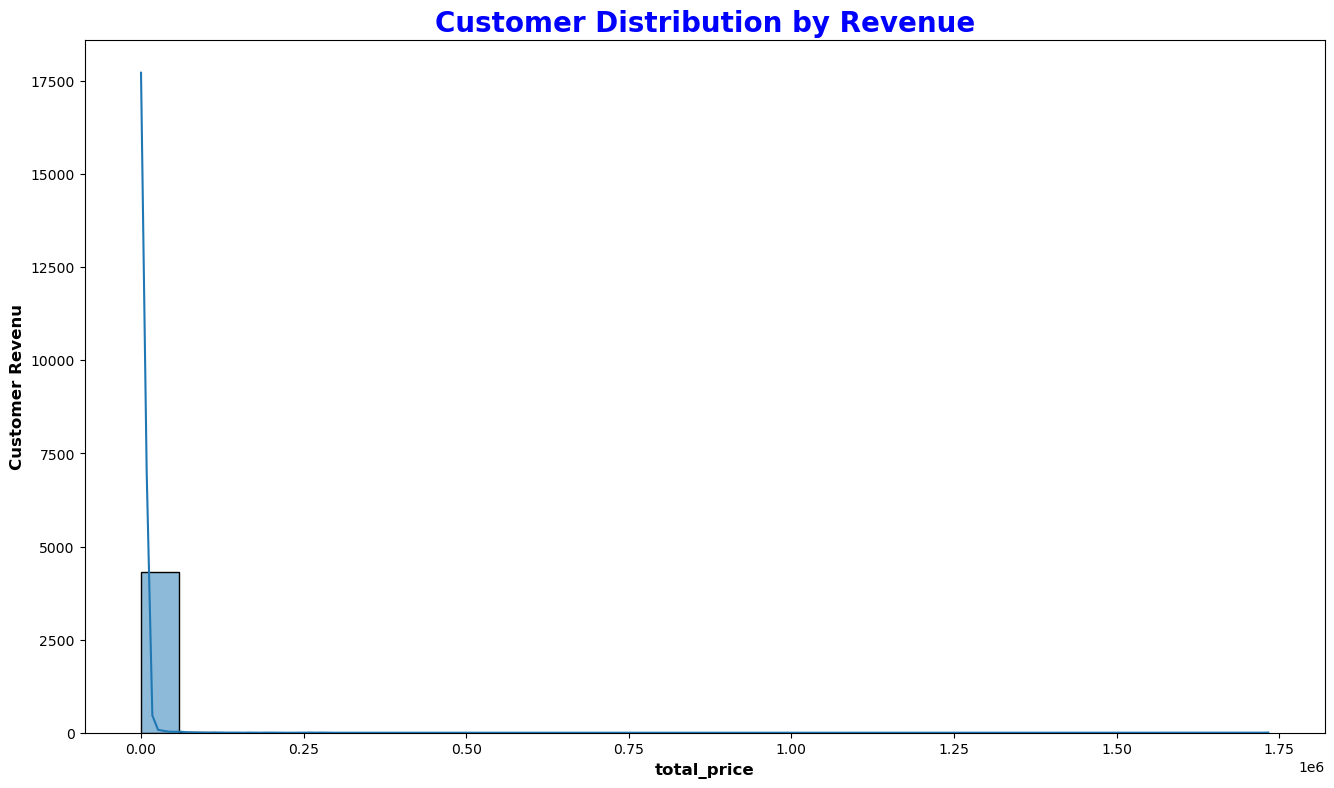

In [34]:
plt.figure(figsize = (16,9))
sns.histplot(customer_revenue, bins = 30, kde = True)
plt.title('Customer Distribution by Revenue', fontsize = 20, fontweight = 'bold', color = 'blue')
plt.xlabel('total_price', fontsize = 12, fontweight = 'bold')
plt.ylabel('Customer Revenu', fontsize = 12, fontweight = 'bold')
plt.show()

## Scatter Plot Frequency Vs Monetary

In [35]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

x1 = rfm['R_Score'] + np.random.uniform(-0.1, 0.1, len(rfm))
x2 = rfm['M_Score'] + np.random.uniform(-0.1, 0.1, len(rfm))
x3 = rfm['F_Score'] + np.random.uniform(-0.1, 0.1, len(rfm))

print(x1, x2, x3)

CustomerID
0.0        4.911145
12346.0    1.056818
12347.0    5.057476
12348.0    2.040185
12349.0    3.913936
             ...   
18280.0    1.036780
18281.0    1.015264
18282.0    5.008626
18283.0    5.019445
18287.0    2.989729
Name: R_Score, Length: 4340, dtype: float64 CustomerID
0.0        5.060233
12346.0    4.911542
12347.0    4.960331
12348.0    4.020361
12349.0    3.962742
             ...   
18280.0    0.966738
18281.0    0.907342
18282.0    0.970067
18283.0    4.977632
18287.0    4.001781
Name: M_Score, Length: 4340, dtype: float64 CustomerID
0.0        5.081594
12346.0    0.971566
12347.0    5.021961
12348.0    4.084738
12349.0    0.965598
             ...   
18280.0    2.026630
18281.0    1.968535
18282.0    2.907362
18283.0    5.034095
18287.0    3.925627
Name: F_Score, Length: 4340, dtype: float64


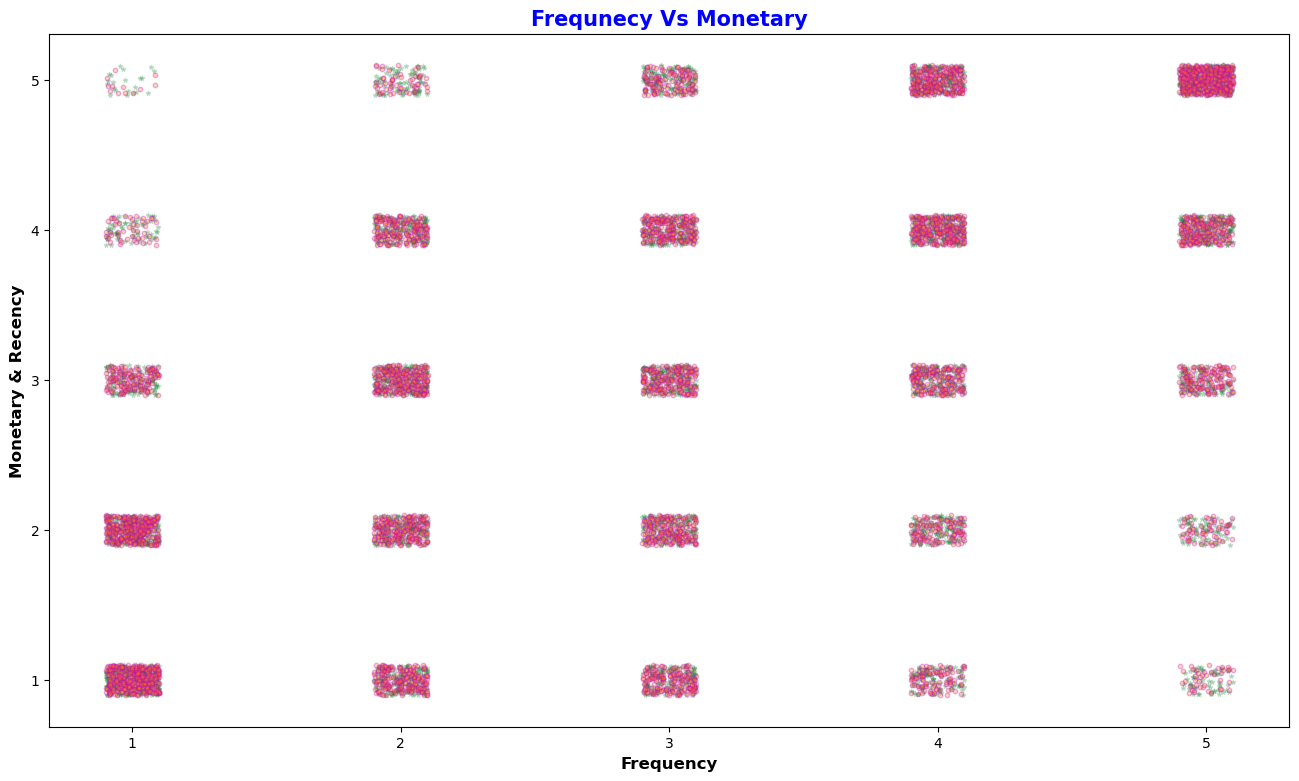

In [36]:
plt.figure(figsize = (16 ,9))
plt.scatter(x1, x2, marker = '*', edgecolor = 'g', s = 10, alpha = 0.2)
plt.scatter(x1, x3, marker = 'o', edgecolor = 'm', s = 10, alpha = 0.3)
plt.title('Frequnecy Vs Monetary', fontsize = 15, fontweight = 'bold', color = 'blue')
plt.xlabel('Frequency', fontsize = 12, fontweight = 'bold')
plt.ylabel('Monetary & Recency', fontsize = 12, fontweight = 'bold')
plt.savefig(r'D:\\Work\\Numpy\\report_images\\scatter_freq_monetary.png')
plt.show()

## RFM Segments

In [37]:
conditions = [
    (rfm['R_Score'] >= 4) & (rfm['M_Score'] >= 4) & (rfm['F_Score'] >= 4),
    (rfm['R_Score'] >= 3) & (rfm['M_Score'] >= 4) & (rfm['F_Score'] >= 4),
    (rfm['R_Score'] <= 2) & (rfm['M_Score'] >= 4) & (rfm['F_Score'] >= 4),
    (rfm['R_Score'] <= 2) & (rfm['M_Score'] >= 3) & (rfm['F_Score'] >= 4),
    (rfm['R_Score'] >= 4) & (rfm['M_Score'] <= 2) & (rfm['F_Score'] <= 2)
]
choices = [
    'Champions',
    'Loyal',
    'At-Risk',
    "Can't loss",
    'New'
]
rfm['Segments'] = np.select(
    conditions,
    choices,
    default = 'others'
)
rfm

,Recency,Frequency,Montary,F_Score,R_Score,M_Score,Segments
CustomerID,,,,,,,
0.0,2011-12-09 10:26:00,2192,1733152.52,5,5,5,Champions
12346.0,2011-01-18 10:01:00,1,77183.60,1,1,5,others
12347.0,2011-12-07 15:52:00,7,4310.00,5,5,5,Champions
12348.0,2011-09-25 13:13:00,4,1797.24,4,2,4,At-Risk
12349.0,2011-11-21 09:51:00,1,1757.55,1,4,4,others
...,...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60,2,1,1,others
18281.0,2011-06-12 10:53:00,1,80.82,2,1,1,others
18282.0,2011-12-02 11:43:00,2,178.05,3,5,1,others


In [38]:
rfm.info

<bound method DataFrame.info of                        Recency  Frequency     Montary  F_Score  R_Score  \
CustomerID                                                                
0.0        2011-12-09 10:26:00       2192  1733152.52        5        5   
12346.0    2011-01-18 10:01:00          1    77183.60        1        1   
12347.0    2011-12-07 15:52:00          7     4310.00        5        5   
12348.0    2011-09-25 13:13:00          4     1797.24        4        2   
12349.0    2011-11-21 09:51:00          1     1757.55        1        4   
...                        ...        ...         ...      ...      ...   
18280.0    2011-03-07 09:52:00          1      180.60        2        1   
18281.0    2011-06-12 10:53:00          1       80.82        2        1   
18282.0    2011-12-02 11:43:00          2      178.05        3        5   
18283.0    2011-12-06 12:02:00         16     2094.88        5        5   
18287.0    2011-10-28 09:29:00          3     1837.28        4      

In [39]:
segment_stats = rfm.groupby('Segments').agg({
    'Recency' : 'mean',
    'Frequency' : ['sum','mean'],
    'Montary' : ['sum', 'mean']
})
segment_stats

Recency Frequency                 Montary  \
                                    mean       sum       mean          sum   
Segments                                                                     
At-Risk    2011-08-08 12:23:14.482758656       959   5.511494   391692.540   
Can't loss 2011-07-14 09:54:16.800000000       305   4.066667    52849.620   
Champions  2011-11-27 12:20:50.316455680     12758  13.457806  7484858.150   
Loyal      2011-10-22 11:41:43.884297472      1554   6.421488   756916.400   
New        2011-11-21 12:56:10.742358016       257   1.122271    55674.220   
others     2011-08-04 09:56:33.458083840      4895   1.831961  1902569.494   

                         
                   mean  
Segments                 
At-Risk     2251.106552  
Can't loss   704.661600  
Champions   7895.419989  
Loyal       3127.753719  
New          243.118865  
others       712.039481

In [40]:
segment_count = rfm['Segments'].value_counts()
segment_count

Segments
others        2672
Champions      948
Loyal          242
New            229
At-Risk        174
Can't loss      75
Name: count, dtype: int64

## Pie Chart Of Segment Stats

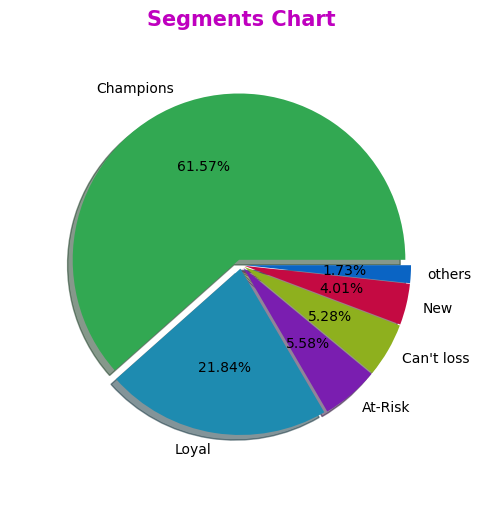

In [41]:
explode = [0.03, 0.02, 0.02, 0.02, 0.02, 0.02]
colors = [
    '#32a852',
    '#1e8bb0',
    '#7a1eb0',
    '#8eb01e',
    '#c40a42',
    '#0a64c4'
]
plt.figure(figsize = (16,6))
plt.pie(segment_count, labels = ['Champions','Loyal','At-Risk',"Can't loss",'New','others'], autopct="%0.2f%%", explode = explode, shadow= True,
       radius = 0.9, colors = colors)
plt.title('Segments Chart', fontsize = 15, fontweight = 'bold', color = 'm')
plt.savefig(r'D:\\Work\\Numpy\\report_images\\segment_pie.png')
plt.show()

In [42]:
# Har segment ka total revenue aur average revenue
segment_revenue = rfm.groupby('Segments')['Montary'].agg(['sum', 'mean', 'count'])
segment_revenue = segment_revenue.sort_values('sum', ascending=False)
print(segment_revenue)

                    sum         mean  count
Segments                                   
Champions   7484858.150  7895.419989    948
others      1902569.494   712.039481   2672
Loyal        756916.400  3127.753719    242
At-Risk      391692.540  2251.106552    174
New           55674.220   243.118865    229
Can't loss    52849.620   704.661600     75


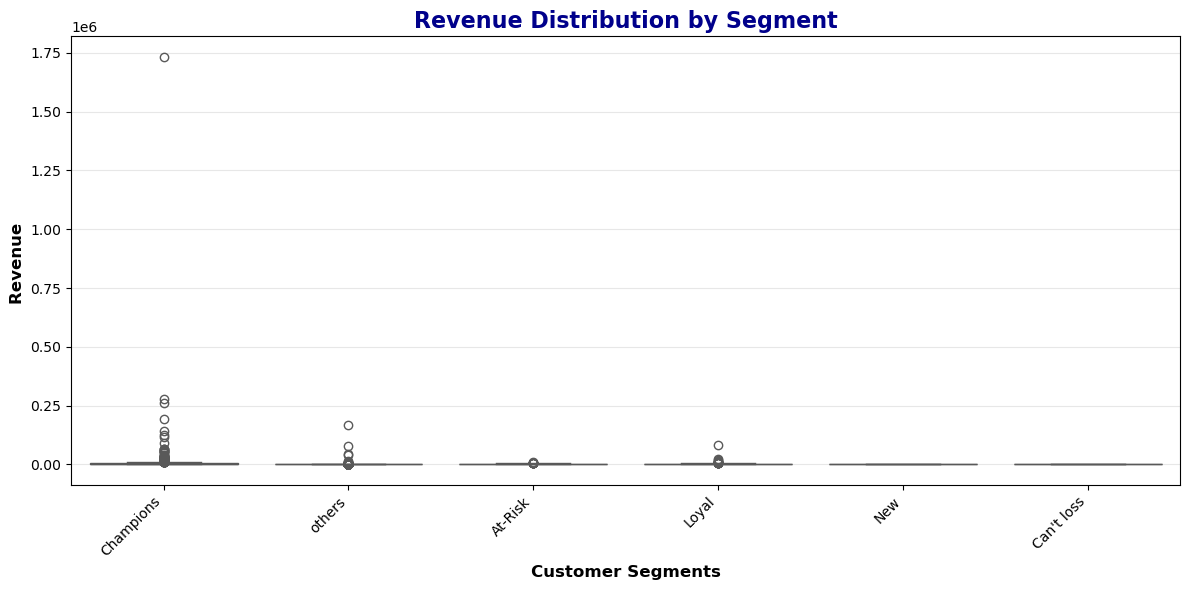

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=rfm, x='Segments', y='Montary',hue='Segments', palette='Set2')

plt.title('Revenue Distribution by Segment', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Customer Segments', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\\Work\\Numpy\\report_images\\revenue_boxplot.png')
plt.show()

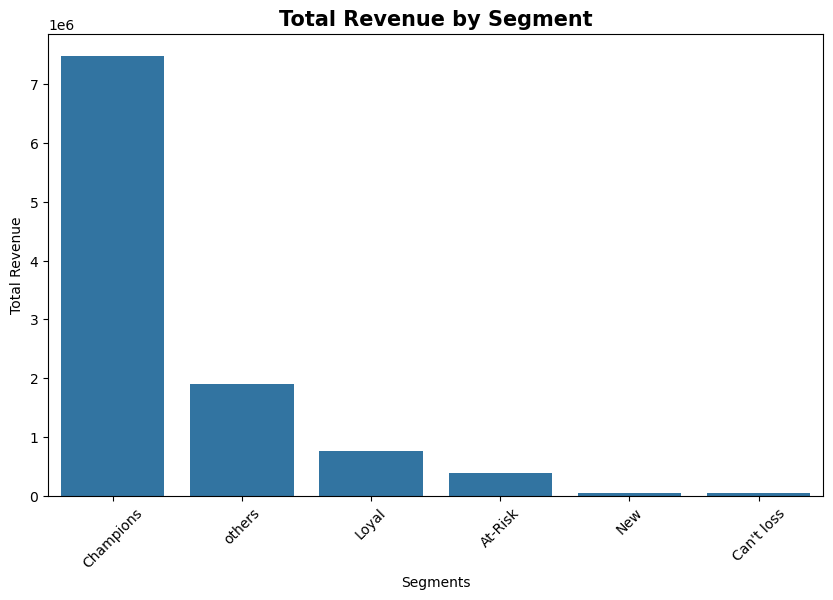

In [44]:
segment_revenue = rfm.groupby('Segments')['Montary'].sum().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values)
plt.title('Total Revenue by Segment', fontsize=15, fontweight='bold')
plt.xlabel('Segments')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.savefig(r'D:\\Work\\Numpy\\report_images\\revenue_bar.png')
plt.show()

## Report

In [46]:
report = f"""
\t\t Data Analysis and Report
\n\t Total rows : {rows} -> Total Columns {columns}
\n\t Total Revenu : {total_revenu}
\n\t Total Number Of Orders : {total_orders}
\n\t Total Sold Quantity : {total_sold_quantity}
\n\t Avg Order Value : {avg_order_value}
\n\t Last Order date : {last_order_date}
\n\t Last Order Day : {last_order_day}
"""
print(report)


		 Data Analysis and Report

	 Total rows : 531285 -> Total Columns 10

	 Total Revenu : 10644560.424

	 Total Number Of Orders : 531285

	 Total Sold Quantity : 5660981

	 Avg Order Value : 20.035499635788703

	 Last Order date : CustomerID
0.0       2011-12-09 10:26:00
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
                  ...        
18280.0   2011-03-07 09:52:00
18281.0   2011-06-12 10:53:00
18282.0   2011-12-02 11:43:00
18283.0   2011-12-06 12:02:00
18287.0   2011-10-28 09:29:00
Name: InvoiceDate, Length: 4340, dtype: datetime64[ns]

	 Last Order Day : CustomerID
0.0          1
12346.0    326
12347.0      2
12348.0     75
12349.0     19
          ... 
18280.0    278
18281.0    181
18282.0      8
18283.0      4
18287.0     43
Name: InvoiceDate, Length: 4340, dtype: int64

